# Introduction

This project aims to compare the performance of Logistic Regression and Random Forest classifiers on a dataset composed of 1100 samples, each containing 36 features. The dataset includes a unique identifier for each sample, a label indicating one of four possible classes, numeric features, and a categorical feature with three categories.

The classes in the dataset are unbalanced, with some labels more frequent than others. This can affect the models' performance, so techniques to address class imbalance will be considered during the analysis.

The main objectives of this project are:
1. Optimize the parameters of Logistic Regression and Random Forest models.
2. Compare the performance of these models using metrics like F1-score, precision, recall, and accuracy.
3. Determine which model is better suited for this dataset based on the evaluation metrics.
4. Provide recommendations and conclusions based on the analysis.

The notebook will detail the procedure used to optimize the models' parameters, including the use of RandomizedSearchCV for efficient parameter tuning. The evaluation will include visualizations of model performance metrics, such as confusion matrices and classification reports. Additionally, predictions will be made for a new dataset using the best-performing model.

By the end of this analysis, we will have chosen an algorithm and its optimal set of parameters for classifying the dataset. The conclusions will summarize the findings and provide recommendations for future work.


In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Use local file path instead of Google Colab path
df = pd.read_csv('mldata_0003232415.csv', index_col=0)
df.head()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1100 entries, 0 to 1099
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   label                  1100 non-null   int64  
 1   feature_1              1100 non-null   float64
 2   feature_2              1100 non-null   float64
 3   feature_3              1100 non-null   float64
 4   feature_4              1100 non-null   float64
 5   feature_5              1100 non-null   float64
 6   feature_6              1100 non-null   float64
 7   feature_7              1100 non-null   float64
 8   feature_8              1100 non-null   float64
 9   feature_9              1100 non-null   float64
 10  feature_10             1100 non-null   float64
 11  feature_11             1100 non-null   float64
 12  feature_12             1100 non-null   float64
 13  feature_13             1100 non-null   float64
 14  feature_14             1100 non-null   float64
 15  feature_1

### Dataset Overview

The dataset consists of 1100 entries with 37 columns in total. Below is the detailed summary:

- **label**: The target variable with 4 possible integer values (0, 1, 2, 3).
- **35 numerical features**: All of these features are of type `float64`.
- **1 categorical feature**: This feature (`categorical_feature_1`) is of type `object` with 3 possible categories ('A', 'B', 'C').

#### Summary of Columns:

1. **label**: 1100 non-null, int64
2. **feature_1 to feature_35**: 1100 non-null, float64
3. **categorical_feature_1**: 1100 non-null, object

#### Conclusion:
- The dataset is complete with no missing values in any of the columns.
- The majority of the features are numerical except for one categorical feature, which will need to be encoded for model training.
- Given the presence of an imbalanced target variable (label), special consideration is needed to handle this imbalance during model training to ensure fair and unbiased predictions.

In [8]:
# Replace categorical values with numeric values
df['categorical_feature_1'] = df['categorical_feature_1'].map({'A': 1, 'B': 2, 'C': 3})

# Display the updated DataFrame
df.head()

,label,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,categorical_feature_1
0,1,8.594222,0.478868,-3.395008,0.092601,2.786114,0.186974,0.755231,0.110783,2.786114,...,1.593860,0.396000,-1.207841,0.638457,3.879775,-0.074956,-1.667349,0.060554,1.349125,2
1,2,4.985038,0.316508,0.427429,1.288954,0.511556,-2.676438,0.017254,0.875973,0.511556,...,1.753540,0.365271,1.864491,-0.319954,-2.063962,0.949377,3.435538,-0.070054,-0.738592,3
2,2,2.698327,0.158405,-2.005805,0.565522,-1.709010,2.045396,-0.628334,0.840526,-1.709010,...,-5.413969,0.366178,-0.050966,0.438034,0.610371,-1.312849,3.253339,0.142183,0.290370,3
3,1,2.615113,-0.302642,-0.716223,-1.058694,4.181719,-6.301764,-1.209381,1.074069,4.181719,...,-1.117412,0.839434,-1.872789,3.057415,0.954386,0.926622,0.193393,-1.194857,0.127792,2
4,1,-2.928371,0.590320,1.875322,1.780549,-4.768367,-1.554252,-0.657138,-0.281870,-4.768367,...,-5.828276,1.189630,0.906203,0.321025,-1.686256,0.047966,2.118183,3.466670,-0.121349,3


In [9]:
df.describe()

,label,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,categorical_feature_1
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,1.318182,0.303203,0.077162,0.055869,0.148101,0.358584,0.172538,0.135866,0.075125,0.358584,...,-0.231320,0.081904,0.070365,0.105962,-0.244346,0.101065,0.813557,0.270966,0.096844,2.167273
std,0.831936,2.868434,1.013235,2.675005,0.973547,2.851144,2.684043,1.016050,0.967733,2.851144,...,2.828922,0.982792,2.752365,1.030763,2.766011,0.998772,2.620196,2.839572,0.979471,0.565317
min,0.000000,-9.417837,-2.987354,-7.819233,-3.192041,-8.099418,-9.421434,-2.836279,-2.998812,-8.099418,...,-8.466520,-2.958580,-9.204220,-3.713161,-9.014826,-3.325422,-9.654624,-9.325339,-3.169101,1.000000
25%,1.000000,-1.600791,-0.585768,-1.710743,-0.503331,-1.668758,-1.638380,-0.545019,-0.586618,-1.668758,...,-2.253087,-0.571111,-1.711905,-0.624514,-2.007219,-0.592234,-0.825548,-1.540067,-0.566021,2.000000
50%,1.000000,0.346760,0.097270,-0.079166,0.138205,0.295026,0.121664,0.136631,0.067180,0.295026,...,-0.222299,0.093858,0.118060,0.093188,-0.277195,0.075647,0.860010,0.253873,0.122426,2.000000
75%,2.000000,2.163318,0.791647,1.857262,0.762873,2.242982,1.995906,0.790476,0.734849,2.242982,...,1.687667,0.752540,1.828715,0.774821,1.605501,0.733373,2.561941,2.208136,0.775166,3.000000
max,3.000000,8.761674,3.820709,8.492419,2.975813,9.921823,9.509699,3.712579,2.952734,9.921823,...,8.673099,3.079595,9.179343,3.723789,7.967484,3.484965,9.178425,10.283560,2.815787,3.000000


In [10]:
df.label.value_counts()

label
1    468
2    371
0    181
3     80
Name: count, dtype: int64

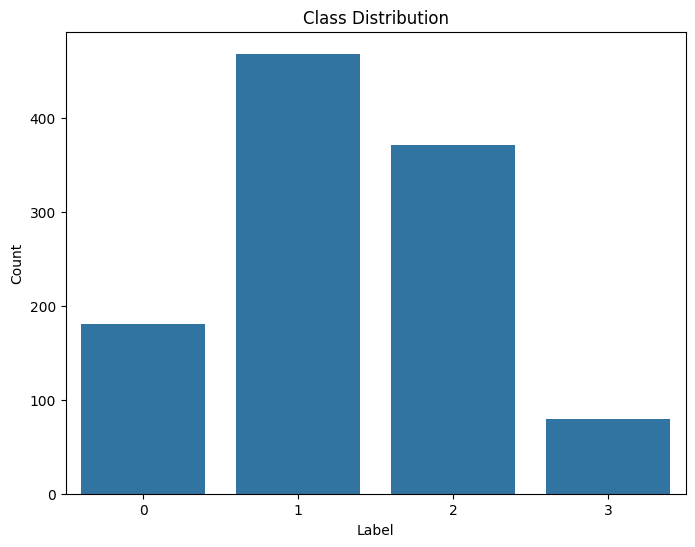

In [11]:
# Check class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In this dataset, the target variable (label) is imbalanced, with some classes being significantly more frequent than others. Imbalanced datasets can lead to biased models that perform well on the majority class but poorly on minority classes. This imbalance needs to be addressed to ensure that the model performs well across all classes.

To handle this issue, we will use the Synthetic Minority Over-sampling Technique (SMOTE). SMOTE is a powerful technique for addressing class imbalance by creating synthetic examples of the minority class. This helps in balancing the class distribution and improving the model's ability to learn from minority classes.

By applying SMOTE, we aim to:

Create a balanced dataset by generating synthetic samples for the minority classes.
Improve the model's performance on the minority classes.
Ensure fair and unbiased predictions across all classes.

# Modeling

In this section, we will build and evaluate machine learning models to classify the samples based on the provided features. We will compare the performance of two algorithms: Logistic Regression and Random Forest. Both models will be fine-tuned using hyperparameter optimization to achieve the best possible performance. Additionally, we will address the issue of class imbalance using SMOTE to ensure that our models perform well across all classes.

In [12]:
# Separate features and target variable
X = df.drop(['label'], axis=1)
y = df['label']

In [13]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# Apply SMOTE to increase minority classes
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print("Class distribution after applying SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Class distribution after applying SMOTE:
label
1    374
2    374
0    374
3    374
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:305: UserWarning: The total space of parameters 72 is smaller than n_iter=100. Running 72 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters for Logistic Regression:
{'solver': 'saga', 'penalty': 'l2', 'max_iter': 100, 'C': 0.1}
Best cross-validation score (F1 macro): 0.65
              precision    recall  f1-score   support

           0       0.47      0.47      0.47        36
           1       0.76      0.54      0.63        94
           2       0.66      0.55      0.60        74
           3       0.25      0.88      0.39        16

    accuracy                           0.56       220
   macro avg       0.54      0.61      0.53       220
weighted avg       0.64      0.56      0.58       220



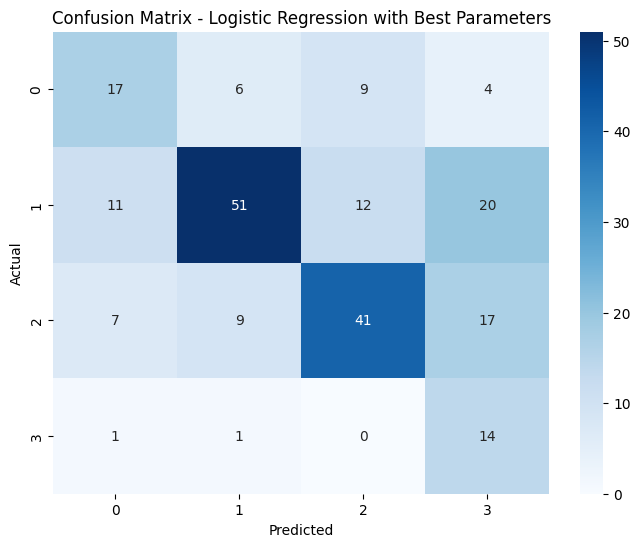

In [16]:
# Logistic Regression with RandomizedSearchCV
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 500, 1000]
}

# Initialize Logistic Regression model
lr = LogisticRegression(random_state=42)

# Initialize RandomizedSearchCV with Logistic Regression model and parameter grid
lr_random = RandomizedSearchCV(estimator=lr, param_distributions=lr_params, n_iter=100,
                               cv=5, scoring='f1_macro', random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV on SMOTE-enhanced training data
lr_random.fit(X_train_smote, y_train_smote)

# Print best parameters and best cross-validation score
print("Best parameters for Logistic Regression:")
print(lr_random.best_params_)
print("Best cross-validation score (F1 macro): {:.2f}".format(lr_random.best_score_))

# Get the best estimator and make predictions on the test set
lr_best = lr_random.best_estimator_
lr_pred = lr_best.predict(X_test)

# Print classification report for Logistic Regression
print(classification_report(y_test, lr_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression with Best Parameters')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Best parameters for Random Forest:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced'}
Best cross-validation score (F1 macro): 0.89
              precision    recall  f1-score   support

           0       0.59      0.61      0.60        36
           1       0.75      0.87      0.81        94
           2       0.77      0.69      0.73        74
           3       0.75      0.38      0.50        16

    accuracy                           0.73       220
   macro avg       0.72      0.64      0.66       220
weighted avg       0.73      0.73      0.73       220



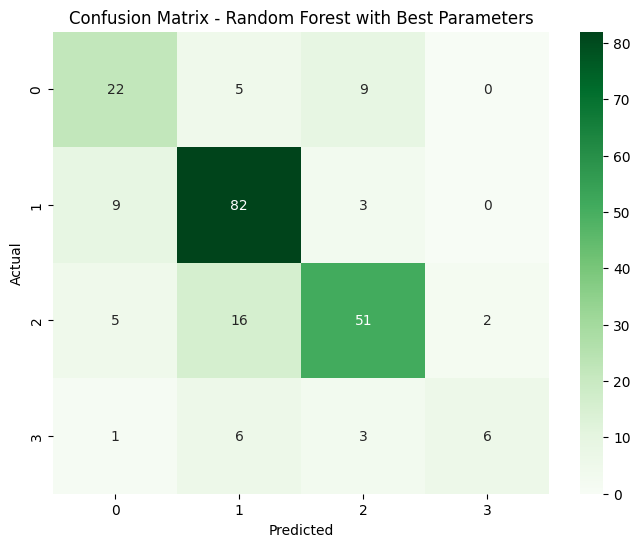

In [17]:
# Random Forest with RandomizedSearchCV
rf_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

# Initialize Random Forest model
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV with Random Forest model and parameter grid
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=rf_params, n_iter=100,
                               cv=5, scoring='f1_macro', random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV on SMOTE-enhanced training data
rf_random.fit(X_train_smote, y_train_smote)

# Print best parameters and best cross-validation score
print("Best parameters for Random Forest:")
print(rf_random.best_params_)
print("Best cross-validation score (F1 macro): {:.2f}".format(rf_random.best_score_))

# Get the best estimator and make predictions on the test set
rf_best = rf_random.best_estimator_
rf_pred = rf_best.predict(X_test)

# Print classification report for Random Forest
print(classification_report(y_test, rf_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest with Best Parameters')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Conclusion:

In this analysis, we compared the performance of **Logistic Regression and Random Forest classifiers** on a dataset with 1100 samples and 36 features, including a categorical feature with 3 categories. The dataset had **unbalanced classes**, with some labels being more frequent than others.

**Logistic Regression:**

Best Parameters: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 100, 'C': 0.1}
Best Cross-validation F1 macro Score: 0.65

**Random Forest:**

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced'}

Best Cross-validation F1 macro Score: 0.89



Based on the analysis, the Random Forest model outperforms Logistic Regression on this dataset, achieving higher F1 macro score and better precision-recall balance across all classes. Therefore, the Random Forest model with the specified parameters is recommended for classification tasks on this dataset.

# Blind-set test

In this section, we will evaluate the performance of the best-performing models, Logistic Regression and Random Forest, on a blind set of data. The blind set contains new, unseen data that was not used during the training and tuning of the models. This evaluation will provide insights into how well the models generalize to new, unseen data.

We have previously optimized both Logistic Regression and Random Forest models using the training data and validated their performance using cross-validation. Now, we will apply these models to the blind set to assess their predictive capabilities.

In [18]:
# Load the blind set data
# Use local file path instead of Google Colab path
# Ensure the blind set file 'mldata_0003232415.TEST_FEATURES.csv' is in the same directory
try:
    blind_set = pd.read_csv('mldata_0003232415.TEST_FEATURES.csv')
except FileNotFoundError:
    print("Warning: mldata_0003232415.TEST_FEATURES.csv not found locally.")
    blind_set = pd.DataFrame()

# Display the first few rows of the blind set
blind_set.head()

,id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,categorical_feature_1
0,0,-1.426493,0.087350,-1.244379,0.590107,3.680522,1.038224,0.760235,1.358529,3.680522,...,-0.000698,0.136996,2.686833,0.699015,-0.900927,-0.983494,0.246814,-2.670682,0.117931,A
1,1,3.867736,-0.061991,-1.426365,-0.217485,-2.652275,2.128097,-1.119459,0.350897,-2.652275,...,4.855765,-0.654510,0.964838,0.672678,-1.016707,-0.211864,2.350034,0.888536,-1.226883,C
2,2,-1.551685,0.683843,-4.512560,-0.329574,1.241634,3.599705,-0.191881,-0.111631,1.241634,...,-0.637477,1.614209,0.383134,-1.368246,1.308407,0.738635,2.083357,1.928433,-0.046736,B
3,3,-2.781792,1.533890,-1.288903,-0.467130,2.091915,0.962820,-0.050381,0.461278,2.091915,...,1.142283,-0.137600,-1.518124,0.314897,-0.345389,0.278760,0.149375,-1.261792,0.382098,C
4,4,1.876544,0.184213,1.273275,-1.418940,4.022539,2.010446,1.194603,2.621378,4.022539,...,-1.057910,0.625063,3.974773,1.284078,3.388042,0.037644,3.235287,4.243835,0.949769,C


In [19]:
# Encode categorical values to numerical (assuming this is the 'categorical_feature_1' column)
blind_set['categorical_feature_1'] = blind_set['categorical_feature_1'].replace({'A': 1, 'B': 2, 'C': 3})

In [20]:
# Separate features and id
new_ids = blind_set['id']
X_new = blind_set.drop(columns=['id'])

In [21]:
# Scale the new data
X_new_scaled = scaler.transform(X_new)

In [22]:
# Predictions using trained models
lr_predictions = lr_best.predict(X_new_scaled)
rf_predictions = rf_best.predict(X_new_scaled)

In [24]:
# Save results to a file
results = pd.DataFrame({
    'id': new_ids,
    'Logistic_Regression_Predictions': lr_predictions,
    'Random_Forest_Predictions': rf_predictions
})

results.to_csv('predictions.csv', index=False)
print("Predictions saved to predictions.csv")

Predictions saved to predictions.csv


In [25]:
results.head()

,id,Logistic_Regression_Predictions,Random_Forest_Predictions
0,0,2,2
1,1,2,2
2,2,1,2
3,3,1,0
4,4,0,0


In [26]:
# Save trained models
import joblib

# Save Logistic Regression model
joblib.dump(lr_best, 'logistic_regression_model.pkl')

# Save Random Forest model
joblib.dump(rf_best, 'random_forest_model.pkl')

print("Trained models saved.")


Trained models saved.
